<a href="https://colab.research.google.com/github/BenitoMarculanoRibeiro/tech_challenge_2/blob/20260813-DataAnalysis/infra/lambda/Analise_bases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*** Levantando informações sobre o arquivo base dos dados

In [ ]:
!pip install -q basedosdados

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 14.8 MB/s eta 0:00:00


In [ ]:
import basedosdados as bd
from google.cloud import bigquery

In [ ]:
PROJECT_ID = "primeval-melody-504216-n5"

client = bigquery.Client(project=PROJECT_ID)

print("Projeto configurado:", client.project)

Projeto configurado: primeval-melody-504216-n5


In [ ]:
from google.colab import auth

auth.authenticate_user()

In [ ]:
table_ref = "basedosdados.br_inep_avaliacao_alfabetizacao.alunos"

table = client.get_table(table_ref)

print("Tabela:", table.full_table_id)
print("Número de colunas:", len(table.schema))

Tabela: basedosdados:br_inep_avaliacao_alfabetizacao.alunos
Número de colunas: 12


In [ ]:
for campo in table.schema:
    print(f"{campo.name} → {campo.field_type}")

ano → INTEGER
id_municipio → STRING
id_escola → STRING
id_aluno → STRING
caderno → STRING
serie → STRING
rede → STRING
presenca → STRING
preenchimento_caderno → STRING
alfabetizado → STRING
proficiencia → FLOAT
peso_aluno → FLOAT


## Exploração da tabela: municipio

In [ ]:
table_ref = "basedosdados.br_inep_avaliacao_alfabetizacao.municipio"

In [ ]:
table = client.get_table(table_ref)

print("Tabela:", table.full_table_id)
print("Número de colunas:", len(table.schema))

Tabela: basedosdados:br_inep_avaliacao_alfabetizacao.municipio
Número de colunas: 15


In [ ]:
for campo in table.schema:
    print(f"{campo.name} → {campo.field_type}")

ano → INTEGER
id_municipio → STRING
serie → STRING
rede → STRING
taxa_alfabetizacao → FLOAT
media_portugues → FLOAT
proporcao_aluno_nivel_0 → FLOAT
proporcao_aluno_nivel_1 → FLOAT
proporcao_aluno_nivel_2 → FLOAT
proporcao_aluno_nivel_3 → FLOAT
proporcao_aluno_nivel_4 → FLOAT
proporcao_aluno_nivel_5 → FLOAT
proporcao_aluno_nivel_6 → FLOAT
proporcao_aluno_nivel_7 → FLOAT
proporcao_aluno_nivel_8 → FLOAT


### Observação

A tabela `municipio` apresenta indicadores agregados por município,
incluindo taxa de alfabetização, média de Português e distribuição
dos alunos segundo níveis de proficiência.

O campo `id_municipio` será posteriormente avaliado como possível
chave de relacionamento com as demais bases utilizadas no projeto.

## Exploração da tabela: meta_alfabetizacao_brasil

Tabela que apresenta as informações referentes às metas de
alfabetização em nível nacional.

In [ ]:
table_ref = "basedosdados.br_inep_avaliacao_alfabetizacao.meta_alfabetizacao_brasil"

table = client.get_table(table_ref)

print("Tabela:", table.full_table_id)
print("Número de colunas:", len(table.schema))

Tabela: basedosdados:br_inep_avaliacao_alfabetizacao.meta_alfabetizacao_brasil
Número de colunas: 11


In [ ]:
for campo in table.schema:
    print(f"{campo.name} → {campo.field_type}")

ano → INTEGER
rede → STRING
taxa_alfabetizacao → FLOAT
meta_alfabetizacao_2024 → FLOAT
meta_alfabetizacao_2025 → FLOAT
meta_alfabetizacao_2026 → FLOAT
meta_alfabetizacao_2027 → FLOAT
meta_alfabetizacao_2028 → FLOAT
meta_alfabetizacao_2029 → FLOAT
meta_alfabetizacao_2030 → FLOAT
percentual_participacao → FLOAT


## Exploração da tabela: meta_alfabetizacao_municipio

Tabela que apresenta as informações referentes às metas de
alfabetização em nível municipal.

In [ ]:
table_ref = "basedosdados.br_inep_avaliacao_alfabetizacao.meta_alfabetizacao_municipio"

table = client.get_table(table_ref)

print("Tabela:", table.full_table_id)
print("Número de colunas:", len(table.schema))

Tabela: basedosdados:br_inep_avaliacao_alfabetizacao.meta_alfabetizacao_municipio
Número de colunas: 13


In [ ]:
for campo in table.schema:
    print(f"{campo.name} → {campo.field_type}")

ano → INTEGER
id_municipio → STRING
rede → STRING
taxa_alfabetizacao → FLOAT
meta_alfabetizacao_2024 → FLOAT
meta_alfabetizacao_2025 → FLOAT
meta_alfabetizacao_2026 → FLOAT
meta_alfabetizacao_2027 → FLOAT
meta_alfabetizacao_2028 → FLOAT
meta_alfabetizacao_2029 → FLOAT
meta_alfabetizacao_2030 → FLOAT
nivel_alfabetizacao → INTEGER
percentual_participacao → FLOAT


## Exploração da tabela: meta_alfabetizacao_uf

Tabela que apresenta as informações referentes às metas de
alfabetização por Unidade da Federação (UF).

In [ ]:
table_ref = "basedosdados.br_inep_avaliacao_alfabetizacao.meta_alfabetizacao_uf"

table = client.get_table(table_ref)

print("Tabela:", table.full_table_id)
print("Número de colunas:", len(table.schema))

Tabela: basedosdados:br_inep_avaliacao_alfabetizacao.meta_alfabetizacao_uf
Número de colunas: 12


In [ ]:
for campo in table.schema:
    print(f"{campo.name} → {campo.field_type}")

ano → INTEGER
sigla_uf → STRING
rede → STRING
taxa_alfabetizacao → FLOAT
meta_alfabetizacao_2024 → FLOAT
meta_alfabetizacao_2025 → FLOAT
meta_alfabetizacao_2026 → FLOAT
meta_alfabetizacao_2027 → FLOAT
meta_alfabetizacao_2028 → FLOAT
meta_alfabetizacao_2029 → FLOAT
meta_alfabetizacao_2030 → FLOAT
percentual_participacao → FLOAT


## Exploração da tabela: uf

Tabela de referência das Unidades da Federação, utilizada para
identificação e relacionamento dos estados.

In [ ]:
table_ref = "basedosdados.br_inep_avaliacao_alfabetizacao.uf"

table = client.get_table(table_ref)

print("Tabela:", table.full_table_id)
print("Número de colunas:", len(table.schema))

Tabela: basedosdados:br_inep_avaliacao_alfabetizacao.uf
Número de colunas: 15


In [ ]:
for campo in table.schema:
    print(f"{campo.name} → {campo.field_type}")

ano → INTEGER
sigla_uf → STRING
serie → STRING
rede → STRING
taxa_alfabetizacao → FLOAT
media_portugues → FLOAT
proporcao_aluno_nivel_0 → FLOAT
proporcao_aluno_nivel_1 → FLOAT
proporcao_aluno_nivel_2 → FLOAT
proporcao_aluno_nivel_3 → FLOAT
proporcao_aluno_nivel_4 → FLOAT
proporcao_aluno_nivel_5 → FLOAT
proporcao_aluno_nivel_6 → FLOAT
proporcao_aluno_nivel_7 → FLOAT
proporcao_aluno_nivel_8 → FLOAT


# 🎯 Objetivos da análise — Metas de Alfabetização

A Avaliação da Alfabetização é a base principal deste projeto e tem
como objetivo analisar os resultados de alfabetização e sua relação
com as metas estabelecidas.

Nesta etapa, serão analisadas as tabelas relacionadas às metas em
diferentes níveis geográficos, permitindo posteriormente realizar
cruzamentos com outras bases educacionais.

## Estrutura das tabelas de metas

| Nível | Tabela | Objetivo da análise |
|---|---|---|
| 🇧🇷 Brasil | `meta_alfabetizacao_brasil` | Identificar a meta nacional de alfabetização |
| 🏙️ Município | `meta_alfabetizacao_municipio` | Analisar as metas estabelecidas para cada município |
| 🗺️ UF | `meta_alfabetizacao_uf` | Comparar as metas e resultados entre as Unidades da Federação |
| 📍 Referência | `uf` | Identificar e relacionar as Unidades da Federação |

## 🔎 Perguntas que pretendemos responder

A análise será orientada pelas seguintes perguntas:

### 1. Alcance das metas
- Qual é a meta de alfabetização estabelecida para o período analisado?
- Quais municípios atingiram ou superaram a meta?
- Quais municípios ficaram abaixo da meta?
- Qual é a proporção de municípios que atingiram a meta?

### 2. Comparação entre estados
- Quais Unidades da Federação apresentam os melhores resultados?
- Quais estados apresentam maior distância em relação à meta?
- Existem diferenças relevantes no desempenho entre as UFs?
- Quais estados apresentam maior concentração de municípios abaixo da meta?

### 3. Desempenho e alfabetização
- Existe relação entre a taxa de alfabetização e o alcance da meta?
- Como a distribuição dos níveis de proficiência se relaciona com o
  cumprimento das metas?
- Quais municípios apresentam bons resultados mesmo estando abaixo
  da meta?

### 4. Cruzamento com outras bases
Posteriormente, os resultados das metas poderão ser relacionados a
outras bases educacionais, como:

- **Censo Escolar:** infraestrutura, matrículas, docentes e características das escolas;
- **Indicadores Educacionais:** rendimento, distorção idade-série e outros indicadores;
- **INSE:** nível socioeconômico dos estudantes e das escolas.

Esses cruzamentos permitirão investigar possíveis relações entre o
contexto educacional e socioeconômico e o alcance das metas de
alfabetização.

## 🎯 Resultado esperado

A partir dos cruzamentos, pretende-se construir indicadores que
permitam visualizar:

**Meta → Resultado → Diferença → Contexto educacional → Contexto socioeconômico**

Esses indicadores serão utilizados posteriormente na definição da
**camada GOLD** e na construção da visualização para o Looker Studio.

## Exploração da tabela: dicionario

A tabela `dicionario` é utilizada como tabela de apoio para a
interpretação das variáveis disponibilizadas na base de Avaliação
da Alfabetização.

Nesta etapa, o objetivo é identificar a estrutura da tabela e
verificar quais informações estão disponíveis para auxiliar na
compreensão dos campos utilizados nas demais tabelas da base.

Serão levantados:

- quantidade de colunas;
- nome das colunas;
- tipo de dado de cada coluna.

A consulta do dicionário também será utilizada posteriormente
como apoio à seleção e interpretação das variáveis que poderão
compor os cruzamentos e a camada GOLD.

In [ ]:
table_ref = "basedosdados.br_inep_avaliacao_alfabetizacao.dicionario"

table = client.get_table(table_ref)

print("Tabela:", table.full_table_id)
print("Número de colunas:", len(table.schema))

Tabela: basedosdados:br_inep_avaliacao_alfabetizacao.dicionario
Número de colunas: 5


In [ ]:
for campo in table.schema:
    print(f"{campo.name} → {campo.field_type}")

id_tabela → STRING
nome_coluna → STRING
chave → STRING
cobertura_temporal → STRING
valor → STRING


### Observação

A tabela `dicionario` possui 5 colunas e funciona como uma tabela
de metadados da base.

Os campos `id_tabela` e `nome_coluna` permitem identificar a qual
tabela e variável determinada informação está relacionada. Os
campos `chave`, `cobertura_temporal` e `valor` complementam as
informações necessárias para interpretação das variáveis.

Por se tratar de uma tabela de apoio, seus dados não representam
diretamente os resultados de alfabetização, mas serão utilizados
como referência para interpretação e documentação das demais
tabelas.

## Exploração da tabela: meta_alfabetizacao_brasil

A tabela `meta_alfabetizacao_brasil` apresenta informações
relacionadas às metas de alfabetização em nível nacional.

Nesta etapa, será identificada a estrutura da tabela, incluindo
a quantidade de colunas, os nomes das variáveis e seus respectivos
tipos de dados.

Essas informações serão posteriormente utilizadas para compreender
a referência nacional das metas e apoiar os cruzamentos com os
resultados de alfabetização.

In [ ]:
table_ref = "basedosdados.br_inep_avaliacao_alfabetizacao.meta_alfabetizacao_brasil"

table = client.get_table(table_ref)

print("Tabela:", table.full_table_id)
print("Número de colunas:", len(table.schema))

Tabela: basedosdados:br_inep_avaliacao_alfabetizacao.meta_alfabetizacao_brasil
Número de colunas: 11


In [ ]:
for campo in table.schema:
    print(f"{campo.name} → {campo.field_type}")

ano → INTEGER
rede → STRING
taxa_alfabetizacao → FLOAT
meta_alfabetizacao_2024 → FLOAT
meta_alfabetizacao_2025 → FLOAT
meta_alfabetizacao_2026 → FLOAT
meta_alfabetizacao_2027 → FLOAT
meta_alfabetizacao_2028 → FLOAT
meta_alfabetizacao_2029 → FLOAT
meta_alfabetizacao_2030 → FLOAT
percentual_participacao → FLOAT


### Observação

A tabela `meta_alfabetizacao_brasil` possui 11 colunas e apresenta
informações agregadas em nível nacional.

Além do ano, rede de ensino e taxa de alfabetização, a tabela
disponibiliza metas de alfabetização projetadas para o período de
2024 a 2030 e o percentual de participação.

A presença da taxa de alfabetização e das metas em uma mesma tabela
permite, posteriormente, avaliar a distância entre o resultado
observado e as metas estabelecidas.

## Exploração da tabela: meta_alfabetizacao_municipio

A tabela `meta_alfabetizacao_municipio` apresenta informações
relacionadas às metas de alfabetização em nível municipal.

O levantamento de sua estrutura permitirá identificar as variáveis
disponíveis para análise dos municípios e avaliar posteriormente
sua relação com os resultados de alfabetização e demais indicadores
educacionais.

Nesta etapa serão identificados:
- quantidade de colunas;
- nome das variáveis;
- tipo de dado de cada variável.

In [ ]:
table_ref = "basedosdados.br_inep_avaliacao_alfabetizacao.meta_alfabetizacao_municipio"

table = client.get_table(table_ref)

print("Tabela:", table.full_table_id)
print("Número de colunas:", len(table.schema))

Tabela: basedosdados:br_inep_avaliacao_alfabetizacao.meta_alfabetizacao_municipio
Número de colunas: 13


In [ ]:
for campo in table.schema:
    print(f"{campo.name} → {campo.field_type}")

ano → INTEGER
id_municipio → STRING
rede → STRING
taxa_alfabetizacao → FLOAT
meta_alfabetizacao_2024 → FLOAT
meta_alfabetizacao_2025 → FLOAT
meta_alfabetizacao_2026 → FLOAT
meta_alfabetizacao_2027 → FLOAT
meta_alfabetizacao_2028 → FLOAT
meta_alfabetizacao_2029 → FLOAT
meta_alfabetizacao_2030 → FLOAT
nivel_alfabetizacao → INTEGER
percentual_participacao → FLOAT


### Observação

A tabela `meta_alfabetizacao_municipio` possui 13 colunas e apresenta
informações agregadas em nível municipal.

Além da taxa e do nível de alfabetização, a tabela disponibiliza
metas projetadas para o período de 2024 a 2030, percentual de
participação e o identificador `id_municipio`.

O campo `id_municipio` será posteriormente avaliado como chave de
relacionamento com outras tabelas da base de Avaliação da
Alfabetização e com bases educacionais adicionais que possuam o
mesmo identificador ou mecanismo de correspondência municipal.

## Exploração da tabela: meta_alfabetizacao_uf

A tabela `meta_alfabetizacao_uf` apresenta informações relacionadas
às metas de alfabetização por Unidade da Federação (UF).

O levantamento permitirá identificar as variáveis disponíveis para
comparação dos resultados e das metas entre os estados brasileiros.

Nesta etapa serão identificados:
- quantidade de colunas;
- nome das variáveis;
- tipo de dado de cada variável.

In [ ]:
table_ref = "basedosdados.br_inep_avaliacao_alfabetizacao.meta_alfabetizacao_uf"

table = client.get_table(table_ref)

print("Tabela:", table.full_table_id)
print("Número de colunas:", len(table.schema))

Tabela: basedosdados:br_inep_avaliacao_alfabetizacao.meta_alfabetizacao_uf
Número de colunas: 12


In [ ]:
for campo in table.schema:
    print(f"{campo.name} → {campo.field_type}")

ano → INTEGER
sigla_uf → STRING
rede → STRING
taxa_alfabetizacao → FLOAT
meta_alfabetizacao_2024 → FLOAT
meta_alfabetizacao_2025 → FLOAT
meta_alfabetizacao_2026 → FLOAT
meta_alfabetizacao_2027 → FLOAT
meta_alfabetizacao_2028 → FLOAT
meta_alfabetizacao_2029 → FLOAT
meta_alfabetizacao_2030 → FLOAT
percentual_participacao → FLOAT


## Exploração da tabela: uf

A tabela `uf` é uma tabela de referência das Unidades da Federação
e será utilizada como apoio para identificação e relacionamento dos
estados brasileiros.

Nesta etapa, serão identificados:
- quantidade de colunas;
- nome das variáveis;
- tipo de dado de cada variável.

Posteriormente, essa tabela poderá ser utilizada para facilitar a
apresentação dos resultados por Unidade da Federação e os
cruzamentos com outras bases que possuam informações em nível
estadual.

In [ ]:
table_ref = "basedosdados.br_inep_avaliacao_alfabetizacao.uf"

table = client.get_table(table_ref)

print("Tabela:", table.full_table_id)
print("Número de colunas:", len(table.schema))

Tabela: basedosdados:br_inep_avaliacao_alfabetizacao.uf
Número de colunas: 15


In [ ]:
for campo in table.schema:
    print(f"{campo.name} → {campo.field_type}")

ano → INTEGER
sigla_uf → STRING
serie → STRING
rede → STRING
taxa_alfabetizacao → FLOAT
media_portugues → FLOAT
proporcao_aluno_nivel_0 → FLOAT
proporcao_aluno_nivel_1 → FLOAT
proporcao_aluno_nivel_2 → FLOAT
proporcao_aluno_nivel_3 → FLOAT
proporcao_aluno_nivel_4 → FLOAT
proporcao_aluno_nivel_5 → FLOAT
proporcao_aluno_nivel_6 → FLOAT
proporcao_aluno_nivel_7 → FLOAT
proporcao_aluno_nivel_8 → FLOAT


### Observação

A tabela `uf` possui 15 colunas e apresenta informações agregadas
por Unidade da Federação.

Além da identificação da UF, ano, série e rede de ensino, a tabela
contém indicadores de alfabetização, média de Português e a
proporção de alunos distribuída entre os níveis de desempenho de 0
a 8.

O campo `sigla_uf` poderá ser utilizado como referência para
relacionamentos em nível estadual, especialmente nas análises
comparativas entre as Unidades da Federação.

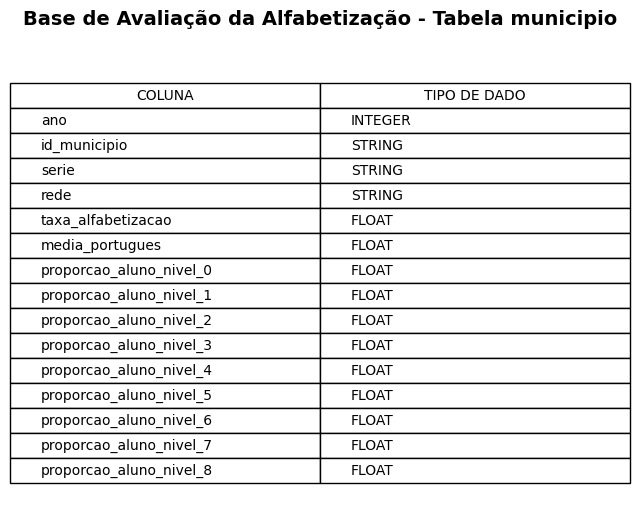

In [ ]:
import matplotlib.pyplot as plt

# Referência da tabela
table_ref = "basedosdados.br_inep_avaliacao_alfabetizacao.municipio"

# Consulta os metadados da tabela
table = client.get_table(table_ref)

# Monta os dados da tabela
dados = [
    [campo.name, campo.field_type]
    for campo in table.schema
]

# Cria a figura
fig, ax = plt.subplots(figsize=(8, 6))

ax.axis("off")

# Título
ax.set_title(
    "Base de Avaliação da Alfabetização - Tabela municipio",
    fontsize=14,
    fontweight="bold",
    pad=20
)

# Cria a tabela
tabela = ax.table(
    cellText=dados,
    colLabels=["COLUNA", "TIPO DE DADO"],
    loc="center",
    cellLoc="left"
)

# Ajustes de visualização
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1, 1.5)

# Salva a imagem
plt.savefig(
    "estrutura_tabela_municipio.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# Inventário da Base Principal

## Base: `br_inep_avaliacao_alfabetizacao`

A base de Avaliação da Alfabetização é a base principal do projeto.
Abaixo está o inventário das tabelas identificadas, seus campos e
respectivos tipos de dados.

---

## 1. Tabela `alunos`

**Quantidade de colunas:** 12

| Campo | Tipo |
|---|---|
| `ano` | INTEGER |
| `id_municipio` | STRING |
| `id_escola` | STRING |
| `id_aluno` | STRING |
| `caderno` | STRING |
| `serie` | STRING |
| `rede` | STRING |
| `presenca` | STRING |
| `preenchimento_caderno` | STRING |
| `alfabetizado` | STRING |
| `proficiencia` | FLOAT |
| `peso_aluno` | FLOAT |

**Finalidade:** dados relacionados aos alunos participantes da
avaliação, incluindo informações de identificação, participação,
alfabetização e proficiência.

---

## 2. Tabela `municipio`

**Quantidade de colunas:** 15

| Campo | Tipo |
|---|---|
| `ano` | INTEGER |
| `id_municipio` | STRING |
| `serie` | STRING |
| `rede` | STRING |
| `taxa_alfabetizacao` | FLOAT |
| `media_portugues` | FLOAT |
| `proporcao_aluno_nivel_0` | FLOAT |
| `proporcao_aluno_nivel_1` | FLOAT |
| `proporcao_aluno_nivel_2` | FLOAT |
| `proporcao_aluno_nivel_3` | FLOAT |
| `proporcao_aluno_nivel_4` | FLOAT |
| `proporcao_aluno_nivel_5` | FLOAT |
| `proporcao_aluno_nivel_6` | FLOAT |
| `proporcao_aluno_nivel_7` | FLOAT |
| `proporcao_aluno_nivel_8` | FLOAT |

**Finalidade:** indicadores agregados de alfabetização e desempenho
em nível municipal.

---

## 3. Tabela `uf`

**Quantidade de colunas:** 15

| Campo | Tipo |
|---|---|
| `ano` | INTEGER |
| `sigla_uf` | STRING |
| `serie` | STRING |
| `rede` | STRING |
| `taxa_alfabetizacao` | FLOAT |
| `media_portugues` | FLOAT |
| `proporcao_aluno_nivel_0` | FLOAT |
| `proporcao_aluno_nivel_1` | FLOAT |
| `proporcao_aluno_nivel_2` | FLOAT |
| `proporcao_aluno_nivel_3` | FLOAT |
| `proporcao_aluno_nivel_4` | FLOAT |
| `proporcao_aluno_nivel_5` | FLOAT |
| `proporcao_aluno_nivel_6` | FLOAT |
| `proporcao_aluno_nivel_7` | FLOAT |
| `proporcao_aluno_nivel_8` | FLOAT |

**Finalidade:** indicadores agregados de alfabetização e desempenho
em nível estadual.

---

## 4. Tabela `meta_alfabetizacao_brasil`

**Quantidade de colunas:** 11

| Campo | Tipo |
|---|---|
| `ano` | INTEGER |
| `rede` | STRING |
| `taxa_alfabetizacao` | FLOAT |
| `meta_alfabetizacao_2024` | FLOAT |
| `meta_alfabetizacao_2025` | FLOAT |
| `meta_alfabetizacao_2026` | FLOAT |
| `meta_alfabetizacao_2027` | FLOAT |
| `meta_alfabetizacao_2028` | FLOAT |
| `meta_alfabetizacao_2029` | FLOAT |
| `meta_alfabetizacao_2030` | FLOAT |
| `percentual_participacao` | FLOAT |

**Finalidade:** metas e indicadores de alfabetização em nível nacional.

---

## 5. Tabela `meta_alfabetizacao_municipio`

**Quantidade de colunas:** 13

| Campo | Tipo |
|---|---|
| `ano` | INTEGER |
| `id_municipio` | STRING |
| `rede` | STRING |
| `taxa_alfabetizacao` | FLOAT |
| `meta_alfabetizacao_2024` | FLOAT |
| `meta_alfabetizacao_2025` | FLOAT |
| `meta_alfabetizacao_2026` | FLOAT |
| `meta_alfabetizacao_2027` | FLOAT |
| `meta_alfabetizacao_2028` | FLOAT |
| `meta_alfabetizacao_2029` | FLOAT |
| `meta_alfabetizacao_2030` | FLOAT |
| `nivel_alfabetizacao` | INTEGER |
| `percentual_participacao` | FLOAT |

**Finalidade:** metas e indicadores de alfabetização em nível municipal.

---

## 6. Tabela `meta_alfabetizacao_uf`

**Quantidade de colunas:** 12

| Campo | Tipo |
|---|---|
| `ano` | INTEGER |
| `sigla_uf` | STRING |
| `rede` | STRING |
| `taxa_alfabetizacao` | FLOAT |
| `meta_alfabetizacao_2024` | FLOAT |
| `meta_alfabetizacao_2025` | FLOAT |
| `meta_alfabetizacao_2026` | FLOAT |
| `meta_alfabetizacao_2027` | FLOAT |
| `meta_alfabetizacao_2028` | FLOAT |
| `meta_alfabetizacao_2029` | FLOAT |
| `meta_alfabetizacao_2030` | FLOAT |
| `percentual_participacao` | FLOAT |

**Finalidade:** metas e indicadores de alfabetização em nível estadual.

---

## 7. Tabela `dicionario`

**Quantidade de colunas:** 5

| Campo | Tipo |
|---|---|
| `id_tabela` | STRING |
| `nome_coluna` | STRING |
| `chave` | STRING |
| `cobertura_temporal` | STRING |
| `valor` | STRING |

**Finalidade:** tabela de metadados utilizada como apoio à
interpretação das variáveis das demais tabelas.

---

# 🔑 Principais campos para relacionamento

| Campo | Tabelas | Possível utilização |
|---|---|---|
| `id_municipio` | `alunos`, `municipio`, `meta_alfabetizacao_municipio` | Relacionamento em nível municipal |
| `sigla_uf` | `uf`, `meta_alfabetizacao_uf` | Relacionamento em nível estadual |
| `ano` | diversas tabelas | Relacionamento temporal |
| `rede` | diversas tabelas | Segmentação por rede de ensino |
| `serie` | `alunos`, `municipio`, `uf` | Segmentação por série |

---

# 🎯 Visão geral

A estrutura identificada permite trabalhar com diferentes níveis de
granularidade:

**Aluno → Município → UF → Brasil**

e relacionar esses níveis aos respectivos indicadores e metas de
alfabetização.

Os campos de identificação geográfica e temporal serão avaliados
como possíveis chaves para os cruzamentos com as bases adicionais
e para a construção da camada GOLD.

# Consulta de municípios - API IBGE

Para complementar as bases utilizadas no projeto, será utilizada a
API de Localidades do IBGE para obter a relação de municípios
brasileiros.

A API disponibiliza o código IBGE do município e seu respectivo nome,
permitindo relacionar essas informações ao campo `id_municipio`
presente nas tabelas da Base dos Dados.

Endpoint utilizado:

https://servicodados.ibge.gov.br/api/v1/localidades/municipios

A consulta não requer autenticação.

In [11]:
import requests
import pandas as pd

url = "https://servicodados.ibge.gov.br/api/v1/localidades/municipios"

resposta = requests.get(url)
resposta.raise_for_status()

dados = resposta.json()

print(f"Quantidade de registros retornados: {len(dados)}")

Quantidade de registros retornados: 5571


In [4]:
dados[0]

{'id': 1100015,
 'nome': "Alta Floresta D'Oeste",
 'microrregiao': {'id': 11006,
  'nome': 'Cacoal',
  'mesorregiao': {'id': 1102,
   'nome': 'Leste Rondoniense',
   'UF': {'id': 11,
    'sigla': 'RO',
    'nome': 'Rondônia',
    'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}}},
 'regiao-imediata': {'id': 110005,
  'nome': 'Cacoal',
  'regiao-intermediaria': {'id': 1102,
   'nome': 'Ji-Paraná',
   'UF': {'id': 11,
    'sigla': 'RO',
    'nome': 'Rondônia',
    'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}}}}

In [12]:
municipios = pd.DataFrame([
    {
        "id_municipio": str(municipio["id"]),
        "nome_municipio": municipio["nome"]
    }
    for municipio in dados
])

municipios.head()

,id_municipio,nome_municipio
0,1100015,Alta Floresta D'Oeste
1,1100023,Ariquemes
2,1100031,Cabixi
3,1100049,Cacoal
4,1100056,Cerejeiras
